In [10]:
import pandas as pd

In [12]:
std = pd.read_csv('student_placement_synthetic.csv')
std.head()

,branch,college_tier,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
0,ECE,Tier-3,6.70,0,7.6,4.4,49.5,3.7,6.4,0.3,1,4,4,3,2,1,1,14.75
1,Chemical,Tier-2,5.70,0,5.4,7.9,72.0,8.3,6.3,1.9,0,4,0,0,0,0,0,NaN
2,EE,Tier-2,7.19,0,5.6,6.8,79.1,7.4,4.4,5.2,1,3,2,1,2,0,1,19.06
3,CE,Tier-2,6.48,0,5.2,3.1,48.4,5.0,1.1,6.7,1,4,3,0,0,0,0,NaN
4,CSE,Tier-2,6.71,1,5.9,4.7,61.2,4.3,2.7,2.8,1,2,0,3,0,1,1,13.42


In [4]:
std.isna().sum()

branch                           0
college_tier                     0
cgpa                             0
backlogs                         0
coding_skills                    0
dsa_score                        0
aptitude_score                   0
communication_skills             0
ml_knowledge                     0
system_design                    0
internships                      0
projects_count                   0
certifications                   0
hackathons                       0
open_source_contributions        0
extracurriculars                 0
placement_status                 0
salary_package_lpa           31525
dtype: int64

In [5]:
std.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   branch                     100000 non-null  object 
 1   college_tier               100000 non-null  object 
 2   cgpa                       100000 non-null  float64
 3   backlogs                   100000 non-null  int64  
 4   coding_skills              100000 non-null  float64
 5   dsa_score                  100000 non-null  float64
 6   aptitude_score             100000 non-null  float64
 7   communication_skills       100000 non-null  float64
 8   ml_knowledge               100000 non-null  float64
 9   system_design              100000 non-null  float64
 10  internships                100000 non-null  int64  
 11  projects_count             100000 non-null  int64  
 12  certifications             100000 non-null  int64  
 13  hackathons                 100

In [6]:
std.loc[std['placement_status'] == 0, 'salary_package_lpa'] = 0

In [7]:
std.isna().sum()

branch                       0
college_tier                 0
cgpa                         0
backlogs                     0
coding_skills                0
dsa_score                    0
aptitude_score               0
communication_skills         0
ml_knowledge                 0
system_design                0
internships                  0
projects_count               0
certifications               0
hackathons                   0
open_source_contributions    0
extracurriculars             0
placement_status             0
salary_package_lpa           0
dtype: int64

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

#### Salary_package_distribution

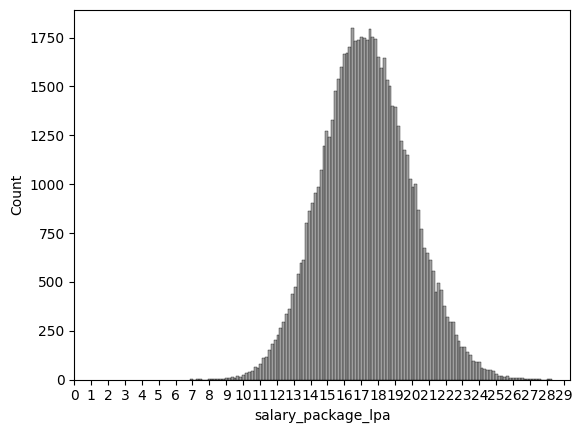

In [13]:
sns.histplot(data=std,x=std['salary_package_lpa'],color='Grey' )
plt.xticks(np.arange(0, 30, 1))
plt.show()

#### Average salary based on Branch

<Axes: xlabel='branch', ylabel='salary_package_lpa'>

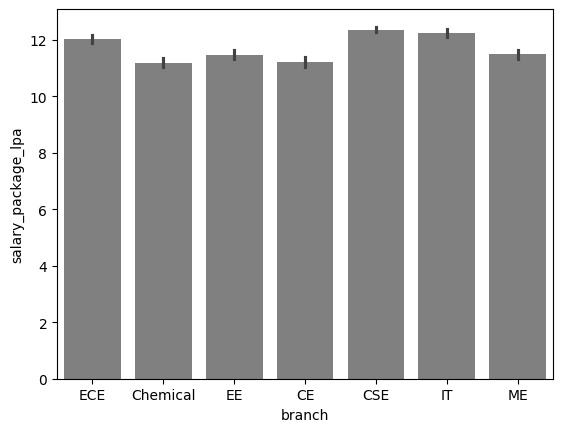

In [68]:
sns.barplot(data=std,x=std['branch'],y=std['salary_package_lpa'],estimator='mean',color='grey')

### 

In [ ]:
std['placement_status'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Placement_distribution')

<Axes: ylabel='count'>

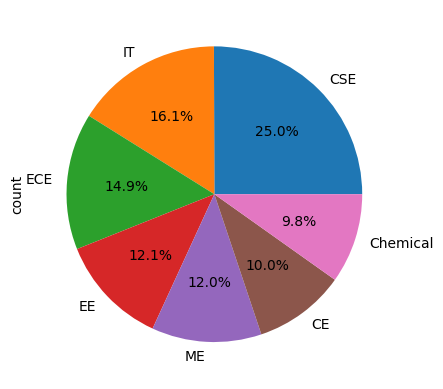

In [76]:
std['branch'].value_counts().plot.pie(autopct='%1.1f%%')

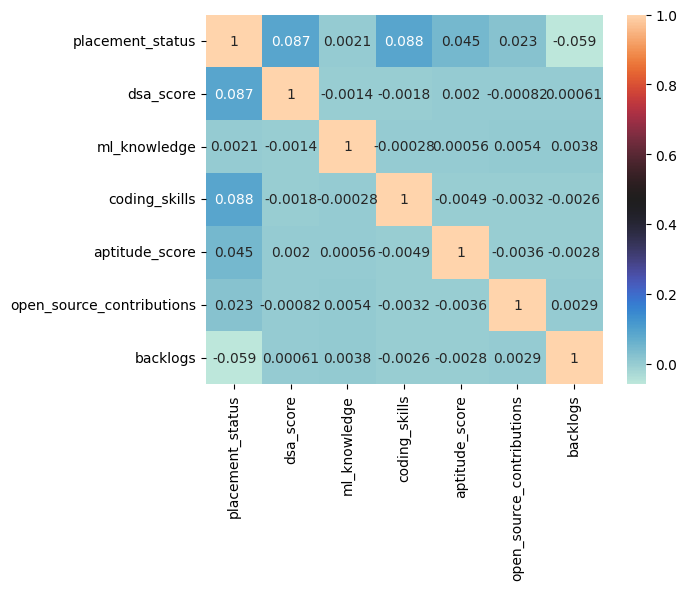

In [94]:
corr = std[['placement_status','dsa_score','ml_knowledge','coding_skills','aptitude_score','open_source_contributions','backlogs']].corr()
sns.heatmap(corr, cmap='icefire', annot=True)
plt.show()

In [114]:
stages_of_placements = {
    "Total Students": len(std),
    "Eligible": len(std[std['cgpa'] > 6]),
    "Strong Coding ": len(std[std['coding_skills'] > 5]),
    "Placed": len(std[std['placement_status'] == 1])
}

In [115]:
stages_of_placements

{'Total Students': 100000,
 'Eligible': 90262,
 'Strong Coding ': 73553,
 'Placed': 68475}

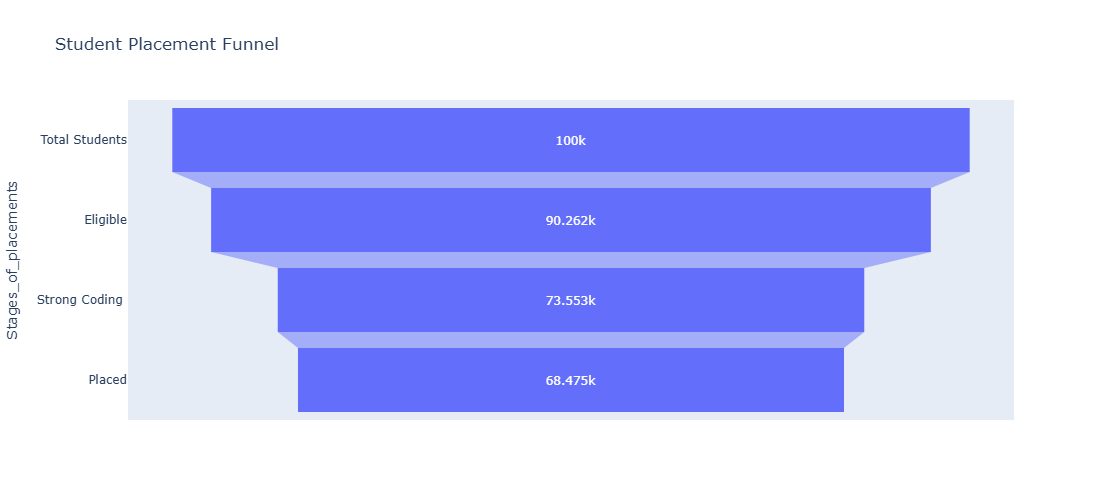

In [122]:
import plotly.express as px
df_funnel = pd.DataFrame({
    "Stages_of_placements": list(stages.keys()),
    "Students": list(stages.values())
})

fig = px.funnel(df_funnel, x="Students", y="Stages_of_placements",
                title="Student Placement Funnel")
fig.update_layout(width=400, height=500)

fig.show()